# Fase 2 — Modelos ML: TF-IDF y GloVe
Implementación y evaluación de LR, RF y SVM con dos representaciones textuales:
TF-IDF y GloVe SBWC en español. Se evalúa por variante dialectal
(mx, es, cu) para cada tipo de preprocesamiento (normal, stem, lemma).

Nested cross-validation con Stratified K-Fold (5 folds) optimizando F1-Macro
(Ortega-Bueno et al., 2022).

El notebook itera automáticamente sobre los tres tipos de preprocesamiento.
GloVe se ejecuta para todos los tipos; se reporta la tasa OOV como diagnóstico.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import gzip, shutil, os, time
import joblib

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, accuracy_score,
    precision_score, recall_score, classification_report,
    confusion_matrix
)

## 2. Configuración

In [2]:
DATA_DIR  = '../data'
GLOVE_GZ  = '../glove-sbwc.i25.vec.gz'
GLOVE_VEC = '../glove-sbwc.i25.vec'

PREPS = ['normal', 'stem', 'lemma']

FEATURE_COLS = ['n_exc', 'n_int', 'n_may', 'n_emo', 'n_ris',
                'n_neg', 'n_elo', 'n_com', 'n_pun']

STOP_WORDS = stopwords.words('spanish')

# Nested CV: outer evalúa estabilidad, inner selecciona hiperparámetros
CV_OUTER = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
CV_INNER = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Preprocesamientos a ejecutar : {PREPS}')
print(f'Features lingüísticos        : {FEATURE_COLS}')
print(f'Outer CV folds               : {CV_OUTER.n_splits}')
print(f'Inner CV folds               : {CV_INNER.n_splits}')

Preprocesamientos a ejecutar : ['normal', 'stem', 'lemma']
Features lingüísticos        : ['n_exc', 'n_int', 'n_may', 'n_emo', 'n_ris', 'n_neg', 'n_elo', 'n_com', 'n_pun']
Outer CV folds               : 5
Inner CV folds               : 5


## 3. Carga de GloVe
Se carga una sola vez antes del bucle principal. Se reporta OOV como diagnóstico
para cada variante de preprocesamiento, pero los experimentos se ejecutan siempre.

(Pennington et al., 2014; Cardellino, 2016)

In [3]:
# Descomprimir si no existe
if not os.path.exists(GLOVE_VEC):
    print('Descomprimiendo GloVe... (puede tardar ~1 min)')
    with gzip.open(GLOVE_GZ, 'rb') as f_in:
        with open(GLOVE_VEC, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print('Descompresión completada.')
else:
    print('Archivo .vec ya existe.')

class GloVeModel:
    def __init__(self, filepath):
        self.key_to_index = {}
        vectors_list = []
        expected_dim = None
        print('Cargando vectores GloVe...')
        t0 = time.time()
        with open(filepath, 'r', encoding='utf-8') as f:
            for i, line in enumerate(f):
                if i % 100000 == 0 and i > 0:
                    print(f'  {i:,} vectores...', end='\r')
                parts = line.rstrip().split(' ')
                if len(parts) < 2:
                    continue
                if len(parts) == 2:
                    try:
                        int(parts[0]); int(parts[1])
                        print(f'Cabecera detectada: {parts[0]} palabras, {parts[1]} dims')
                        continue
                    except ValueError:
                        pass
                word = parts[0]
                try:
                    vector = np.array(parts[1:], dtype=np.float32)
                except ValueError:
                    continue
                if expected_dim is None:
                    expected_dim = len(vector)
                if len(vector) != expected_dim:
                    continue
                self.key_to_index[word] = len(vectors_list)
                vectors_list.append(vector)
        self.vectors     = np.vstack(vectors_list)
        self.vector_size = self.vectors.shape[1]
        print(f'\nListo en {time.time()-t0:.1f}s | '
              f'{len(self.key_to_index):,} vectores | '
              f'{self.vector_size} dimensiones')

    def __contains__(self, word):
        return word in self.key_to_index

    def __getitem__(self, word):
        return self.vectors[self.key_to_index[word]]

glove = GloVeModel(GLOVE_VEC)

Archivo .vec ya existe.
Cargando vectores GloVe...
Cabecera detectada: 855380 palabras, 300 dims
  800,000 vectores...
Listo en 34.7s | 855,380 vectores | 300 dimensiones


In [4]:
def vectorizar_glove(textos, modelo, dim=300):
    """Vectorización por promedio de embeddings GloVe. Reporta tasa OOV."""
    vectores = []
    oov_total, tokens_total = 0, 0
    for texto in textos:
        palabras = str(texto).split()
        tokens_total += len(palabras)
        vecs = [modelo[w] for w in palabras if w in modelo.key_to_index]
        oov_total += len(palabras) - len(vecs)
        vectores.append(np.mean(vecs, axis=0) if vecs else np.zeros(dim))
    oov_rate = oov_total / max(tokens_total, 1) * 100
    return np.array(vectores), oov_rate

## 4. Definición de modelos y grids de hiperparámetros

In [5]:
# ── Pipelines TF-IDF ──
def build_tfidf_prep():
    return ColumnTransformer([
        ('tfidf_word', TfidfVectorizer(
            stop_words=STOP_WORDS,
            max_features=10000
        ), 'MESSAGE_CLEAN'),
        ('ling', 'passthrough', FEATURE_COLS)
    ])

def build_tfidf_pipelines():
    return {
        'LR':  Pipeline([('prep', build_tfidf_prep()),
                         ('clf',  LogisticRegression(max_iter=10000, random_state=42,
                                                     class_weight='balanced'))]),
        'RF':  Pipeline([('prep', build_tfidf_prep()),
                         ('clf',  RandomForestClassifier(random_state=42,
                                                         class_weight='balanced'))]),
        'SVM': Pipeline([('prep', build_tfidf_prep()),
                         ('clf',  LinearSVC(random_state=42, class_weight='balanced',
                                            max_iter=100000))])
    }

GRIDS_TFIDF = {
    'LR': {
        'prep__tfidf_word__ngram_range': [(1,1), (1,2)],
        'clf__C':                        [0.1, 1.0, 10],
        'clf__solver':                   ['liblinear']
    },
    'RF': {
        'prep__tfidf_word__ngram_range': [(1,1), (1,2)],
        'clf__n_estimators':             [100, 200, 300],
        'clf__max_depth':                [None, 10, 20],
        'clf__min_samples_split':        [2, 5]
    },
    'SVM': {
        'prep__tfidf_word__ngram_range': [(1,1), (1,2)],
        'clf__C':                        [0.01, 0.1, 1.0, 10]
    }
}

# ── Pipelines GloVe ──
def build_glove_pipelines():
    return {
        'LR':  Pipeline([('scaler', StandardScaler()),
                         ('clf',    LogisticRegression(max_iter=10000, random_state=42,
                                                       class_weight='balanced'))]),
        'RF':  Pipeline([('scaler', StandardScaler()),
                         ('clf',    RandomForestClassifier(random_state=42,
                                                           class_weight='balanced'))]),
        'SVM': Pipeline([('scaler', StandardScaler()),
                         ('clf',    LinearSVC(random_state=42, class_weight='balanced',
                                              max_iter=100000))])
    }

GRIDS_GLOVE = {
    'LR': {
        'clf__C':      [0.1, 1.0, 10],
        'clf__solver': ['liblinear']
    },
    'RF': {
        'clf__n_estimators':      [100, 200, 300],
        'clf__max_depth':         [None, 10, 20],
        'clf__min_samples_split': [2, 5]
    },
    'SVM': {'clf__C': [0.01, 0.1, 1.0, 10]}
}

print('Pipelines y grids definidos.')

Pipelines y grids definidos.


## 5. Función principal de experimentos
Nested CV: outer loop (5 folds) evalúa estabilidad, inner loop (GridSearchCV)
selecciona hiperparámetros. Reentrenamiento final sobre todo el train
y evaluación en test oficial.

In [6]:
RESULTADOS = []

def run_experimento(prep, dataset_nombre, df_tr, df_te,
                    repr_nombre, build_pipelines_fn, grids,
                    X_tr, y_tr, X_te, y_te):
    """
    Nested CV + reentrenamiento final + evaluación en test.
    Almacena resultados y estimador entrenado en RESULTADOS.
    """
    models_dir = f'{DATA_DIR}/modelos/{prep}'
    os.makedirs(models_dir, exist_ok=True)

    print(f'\n{"="*60}')
    print(f'  PREP={prep} | Dataset={dataset_nombre.upper()} | Repr={repr_nombre}')
    print(f'{"="*60}')

    for modelo_nombre in ['LR', 'RF', 'SVM']:
        grid = grids[modelo_nombre]

        n_cand = 1
        for v in grid.values():
            n_cand *= len(v)

        print(f'\n  → {modelo_nombre} | {n_cand} candidatos | nested CV...')
        t0 = time.time()

        # ── Outer CV loop ──
        outer_scores = []
        for fold_idx, (outer_train_idx, outer_val_idx) in enumerate(
                CV_OUTER.split(X_tr, y_tr)):

            if hasattr(X_tr, 'iloc'):
                X_ot = X_tr.iloc[outer_train_idx]
                X_ov = X_tr.iloc[outer_val_idx]
            else:
                X_ot = X_tr[outer_train_idx]
                X_ov = X_tr[outer_val_idx]

            y_ot = y_tr[outer_train_idx]
            y_ov = y_tr[outer_val_idx]

            pipeline = build_pipelines_fn()[modelo_nombre]
            inner_search = GridSearchCV(
                pipeline, grid,
                cv=CV_INNER, scoring='f1_macro',
                n_jobs=-1, verbose=0
            )
            inner_search.fit(X_ot, y_ot)

            y_pred_ov = inner_search.best_estimator_.predict(X_ov)
            fold_f1 = f1_score(y_ov, y_pred_ov, average='macro')
            outer_scores.append(fold_f1)

        outer_mean = float(np.mean(outer_scores))
        outer_std  = float(np.std(outer_scores))
        print(f'     Outer CV F1-Macro: {outer_mean:.4f} ± {outer_std:.4f}  '
              f'(folds: {[round(s,4) for s in outer_scores]})')

        # ── Reentrenamiento final sobre todo el train set ──
        pipeline_final = build_pipelines_fn()[modelo_nombre]
        final_search = GridSearchCV(
            pipeline_final, grid,
            cv=CV_INNER, scoring='f1_macro',
            n_jobs=-1, verbose=0
        )
        final_search.fit(X_tr, y_tr)

        # ── Evaluación en test set oficial ──
        y_pred = final_search.best_estimator_.predict(X_te)
        acc   = accuracy_score(y_te, y_pred)
        f1m   = f1_score(y_te, y_pred, average='macro')
        p_ir  = precision_score(y_te, y_pred, pos_label=1, zero_division=0)
        r_ir  = recall_score(y_te, y_pred, pos_label=1, zero_division=0)
        f1_ir = f1_score(y_te, y_pred, pos_label=1, zero_division=0)

        print(f'     Test oficial  — F1-Macro={f1m:.4f} | Accuracy={acc:.4f} | '
              f'tiempo total={time.time()-t0:.1f}s')
        print(f'     Mejores params (final): {final_search.best_params_}')

        RESULTADOS.append({
            'prep':           prep,
            'dataset':        dataset_nombre,
            'repr':           repr_nombre,
            'modelo':         modelo_nombre,
            'outer_f1_mean':  round(outer_mean, 4),
            'outer_f1_std':   round(outer_std,  4),
            'f1_macro_inner': round(final_search.best_score_, 4),
            'accuracy':       round(acc,   4),
            'f1_macro':       round(f1m,   4),
            'p_ironico':      round(p_ir,  4),
            'r_ironico':      round(r_ir,  4),
            'f1_ironico':     round(f1_ir, 4),
            'best_params':    final_search.best_params_,
            'estimator':      final_search.best_estimator_
        })

        rep_tag = 'tf-idf' if repr_nombre == 'TF-IDF' else 'glove'
        fname = (f'{models_dir}/ml_{rep_tag}_{modelo_nombre.lower()}'
                 f'_{dataset_nombre}.pkl')
        joblib.dump(final_search.best_estimator_, fname)

print('Función de experimentos lista.')

Función de experimentos lista.


## 6. Bucle principal — todos los preprocesamientos

In [7]:
for PREP in PREPS:
    SUFIJO = '' if PREP == 'normal' else f'_{PREP}'

    print(f'\n{"#"*60}')
    print(f'  PREPROCESAMIENTO: {PREP.upper()}')
    print(f'{"#"*60}')

    df_train_mx = pd.read_csv(f'{DATA_DIR}/train_clean{SUFIJO}_mx.csv')
    df_test_mx  = pd.read_csv(f'{DATA_DIR}/test_clean{SUFIJO}_mx.csv')
    df_train_es = pd.read_csv(f'{DATA_DIR}/train_clean{SUFIJO}_es.csv')
    df_test_es  = pd.read_csv(f'{DATA_DIR}/test_clean{SUFIJO}_es.csv')
    df_train_cu = pd.read_csv(f'{DATA_DIR}/train_clean{SUFIJO}_cu.csv')
    df_test_cu  = pd.read_csv(f'{DATA_DIR}/test_clean{SUFIJO}_cu.csv')

    DATASETS = {
        'mx': (df_train_mx, df_test_mx),
        'es': (df_train_es, df_test_es),
        'cu': (df_train_cu, df_test_cu),
    }

    print(f'Datasets cargados ({PREP}):')
    for nombre, (tr, te) in DATASETS.items():
        print(f'  {nombre:4} train={len(tr):,} | test={len(te):,}')

    # ── Experimentos TF-IDF ──
    print(f'\n--- TF-IDF ({PREP}) ---')
    for ds_nombre, (df_tr, df_te) in DATASETS.items():
        X_tr = df_tr[['MESSAGE_CLEAN'] + FEATURE_COLS]
        y_tr = df_tr['IS_IRONIC'].values
        X_te = df_te[['MESSAGE_CLEAN'] + FEATURE_COLS]
        y_te = df_te['IS_IRONIC'].values

        run_experimento(
            prep=PREP, dataset_nombre=ds_nombre,
            df_tr=df_tr, df_te=df_te,
            repr_nombre='TF-IDF',
            build_pipelines_fn=build_tfidf_pipelines,
            grids=GRIDS_TFIDF,
            X_tr=X_tr, y_tr=y_tr, X_te=X_te, y_te=y_te
        )

    # ── Experimentos GloVe ──
    print(f'\n--- GloVe ({PREP}) ---')
    for ds_nombre, (df_tr, df_te) in DATASETS.items():
        print(f'\nVectorizando GloVe: {ds_nombre} ({PREP})...')

        glove_tr, oov_tr = vectorizar_glove(df_tr['MESSAGE_CLEAN'], glove)
        glove_te, oov_te = vectorizar_glove(df_te['MESSAGE_CLEAN'], glove)

        print(f'  OOV train={oov_tr:.1f}% | OOV test={oov_te:.1f}%'
              + (' [OOV alto: texto preprocesado vs vocabulario GloVe]'
                 if oov_tr > 50 else ''))

        X_tr = np.hstack([glove_tr, df_tr[FEATURE_COLS].values.astype(float)])
        y_tr = df_tr['IS_IRONIC'].values
        X_te = np.hstack([glove_te, df_te[FEATURE_COLS].values.astype(float)])
        y_te = df_te['IS_IRONIC'].values

        run_experimento(
            prep=PREP, dataset_nombre=ds_nombre,
            df_tr=df_tr, df_te=df_te,
            repr_nombre='GloVe',
            build_pipelines_fn=build_glove_pipelines,
            grids=GRIDS_GLOVE,
            X_tr=X_tr, y_tr=y_tr, X_te=X_te, y_te=y_te
        )


############################################################
  PREPROCESAMIENTO: NORMAL
############################################################
Datasets cargados (normal):
  mx   train=2,399 | test=600
  es   train=2,398 | test=600
  cu   train=2,400 | test=600

--- TF-IDF (normal) ---

  PREP=normal | Dataset=MX | Repr=TF-IDF

  → LR | 6 candidatos | nested CV...
     Outer CV F1-Macro: 0.6655 ± 0.0130  (folds: [0.6757, 0.6415, 0.6721, 0.6757, 0.6624])
     Test oficial  — F1-Macro=0.6924 | Accuracy=0.7283 | tiempo total=4.8s
     Mejores params (final): {'clf__C': 1.0, 'clf__solver': 'liblinear', 'prep__tfidf_word__ngram_range': (1, 2)}

  → RF | 36 candidatos | nested CV...
     Outer CV F1-Macro: 0.6306 ± 0.0212  (folds: [0.6402, 0.6284, 0.6519, 0.6415, 0.5909])
     Test oficial  — F1-Macro=0.6255 | Accuracy=0.6683 | tiempo total=107.5s
     Mejores params (final): {'clf__max_depth': 20, 'clf__min_samples_split': 5, 'clf__n_estimators': 200, 'prep__tfidf_word__ngram_range': 

## 7. Resultados sobre train — Experimentación (OE1 + OE2)
Métricas del nested CV (outer loop) y del reentrenamiento final (inner loop).
Estas métricas corresponden al rendimiento sobre los datos de entrenamiento
y se presentan en la sección de Experimentación del artículo.

In [8]:
df_res = pd.DataFrame([{
    'Prep':             r['prep'],
    'Dataset':          r['dataset'],
    'Repr':             r['repr'],
    'Modelo':           r['modelo'],
    'Outer F1 mean':    r['outer_f1_mean'],
    'Outer F1 std':     r['outer_f1_std'],
    'Inner F1 (final)': r['f1_macro_inner'],
    'F1-Macro test':    r['f1_macro'],
    'Accuracy':         r['accuracy'],
    'F1-Irónico':       r['f1_ironico'],
    'P-Irónico':        r['p_ironico'],
    'R-Irónico':        r['r_ironico'],
    'Best Params':      str(r['best_params']),
} for r in RESULTADOS])

# ── Tabla de estabilidad (outer CV) por prep ──
print('RESULTADOS NESTED CV — ESTABILIDAD (para Experimentación)')
print('=' * 80)
for prep in PREPS:
    subset = df_res[df_res['Prep'] == prep]
    print(f'\n  PREP={prep.upper()}')
    print(subset[['Dataset', 'Repr', 'Modelo', 'Outer F1 mean', 'Outer F1 std',
                  'Inner F1 (final)']].to_string(index=False))

# ── Mejores hiperparámetros por combinación ──
print('\n\nMEJORES HIPERPARÁMETROS ENCONTRADOS')
print('=' * 80)
for prep in PREPS:
    subset = df_res[df_res['Prep'] == prep]
    print(f'\n  PREP={prep.upper()}')
    print(subset[['Dataset', 'Repr', 'Modelo', 'Best Params']].to_string(index=False))

RESULTADOS NESTED CV — ESTABILIDAD (para Experimentación)

  PREP=NORMAL
Dataset   Repr Modelo  Outer F1 mean  Outer F1 std  Inner F1 (final)
     mx TF-IDF     LR         0.6655        0.0130            0.6666
     mx TF-IDF     RF         0.6306        0.0212            0.6480
     mx TF-IDF    SVM         0.6650        0.0069            0.6661
     es TF-IDF     LR         0.7071        0.0193            0.7132
     es TF-IDF     RF         0.7070        0.0182            0.7120
     es TF-IDF    SVM         0.7090        0.0125            0.7119
     cu TF-IDF     LR         0.6626        0.0182            0.6587
     cu TF-IDF     RF         0.6586        0.0182            0.6659
     cu TF-IDF    SVM         0.6604        0.0189            0.6594
     mx  GloVe     LR         0.6038        0.0240            0.6038
     mx  GloVe     RF         0.4668        0.0058            0.4731
     mx  GloVe    SVM         0.6028        0.0218            0.6048
     es  GloVe     LR         

## 8. Resultados sobre test — Resultados (OE2)
Métricas de evaluación sobre la partición oficial de test.
Estas métricas se presentan en la sección de Resultados del artículo.

In [9]:
print('RESULTADOS SOBRE TEST OFICIAL')
print('=' * 80)
for prep in PREPS:
    subset = df_res[df_res['Prep'] == prep]
    print(f'\n  PREP={prep.upper()}')
    print(subset[['Dataset', 'Repr', 'Modelo', 'F1-Macro test', 'Accuracy',
                  'P-Irónico', 'R-Irónico', 'F1-Irónico']].to_string(index=False))

    print(f'\n  MEJOR MODELO POR VARIANTE Y REPRESENTACIÓN (PREP={prep.upper()}):')
    for ds in ['mx', 'es', 'cu']:
        for repr_nombre in ['TF-IDF', 'GloVe']:
            sub = subset[
                (subset['Dataset'] == ds) &
                (subset['Repr'] == repr_nombre)
            ]
            if not sub.empty:
                mejor = sub.loc[sub['F1-Macro test'].idxmax()]
                print(f'    {ds:4} {repr_nombre:6} → {mejor["Modelo"]:4}  '
                      f'F1-Macro={mejor["F1-Macro test"]:.4f}  '
                      f'Outer F1={mejor["Outer F1 mean"]:.4f}±{mejor["Outer F1 std"]:.4f}')

# ── Mejor resultado global por variante ──
print(f'\n{"#"*80}')
print(f'  MEJOR RESULTADO GLOBAL POR VARIANTE (criterio: F1-Macro test)')
print(f'{"#"*80}')
print(f'  {"Variante":<10} {"Modelo":<6} {"Repr":<8} {"Prep":<8} '
      f'{"F1-Macro test":>14}  {"Outer F1":>14}  {"Accuracy":>10}')
print(f'  {"-"*72}')
for ds in ['mx', 'es', 'cu']:
    sub = df_res[df_res['Dataset'] == ds]
    if not sub.empty:
        mejor = sub.loc[sub['F1-Macro test'].idxmax()]
        print(f'  {ds:<10} {mejor["Modelo"]:<6} {mejor["Repr"]:<8} {mejor["Prep"]:<8} '
              f'{mejor["F1-Macro test"]:>14.4f}  '
              f'{mejor["Outer F1 mean"]:>7.4f}±{mejor["Outer F1 std"]:.4f}  '
              f'{mejor["Accuracy"]:>10.4f}')

# Exportar CSV consolidado
out_csv = f'{DATA_DIR}/resultados_ml_todos.csv'
df_res.drop(columns='Best Params').to_csv(out_csv, index=False)
print(f'\nCSV consolidado guardado: {out_csv}')

RESULTADOS SOBRE TEST OFICIAL

  PREP=NORMAL
Dataset   Repr Modelo  F1-Macro test  Accuracy  P-Irónico  R-Irónico  F1-Irónico
     mx TF-IDF     LR         0.6924    0.7283     0.5918     0.5829      0.5873
     mx TF-IDF     RF         0.6255    0.6683     0.5000     0.4975      0.4987
     mx TF-IDF    SVM         0.6909    0.7267     0.5888     0.5829      0.5859
     es TF-IDF     LR         0.7154    0.7367     0.5890     0.6950      0.6376
     es TF-IDF     RF         0.6866    0.7283     0.6022     0.5450      0.5722
     es TF-IDF    SVM         0.7227    0.7417     0.5926     0.7200      0.6501
     cu TF-IDF     LR         0.6648    0.7167     0.5915     0.4850      0.5330
     cu TF-IDF     RF         0.6594    0.7167     0.5974     0.4600      0.5198
     cu TF-IDF    SVM         0.6616    0.7167     0.5949     0.4700      0.5251
     mx  GloVe     LR         0.6784    0.7083     0.5550     0.6080      0.5803
     mx  GloVe     RF         0.4658    0.6733     0.5556     0.

## 9. Análisis de contribución de características lingüísticas (OE3)
Se extraen las importancias/coeficientes de las 9 características lingüísticas
para los tres modelos (LR, RF, SVM) por variante dialectal.

Se utiliza el mejor preprocesamiento con TF-IDF (representación dominante).
Para RF se usa `feature_importances_`, para LR y SVM se usa `|coef_|`.

In [10]:
def extraer_importancia_ling(estimator, repr_nombre, modelo_nombre):
    """
    Extrae la importancia de las 9 características lingüísticas
    del estimador entrenado. Retorna dict {feature: importancia}.
    """
    clf = estimator.named_steps.get('clf', estimator)

    # Obtener importancias brutas
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
    elif hasattr(clf, 'coef_'):
        importances = np.abs(clf.coef_[0]) if clf.coef_.ndim > 1 else np.abs(clf.coef_)
    else:
        return None

    # Las 9 features lingüísticas son las últimas 9 del vector
    if repr_nombre == 'TF-IDF':
        try:
            n_tfidf = len(estimator.named_steps['prep']
                         .named_transformers_['tfidf_word']
                         .get_feature_names_out())
            ling_importances = importances[n_tfidf:n_tfidf + len(FEATURE_COLS)]
        except Exception:
            return None
    else:
        # GloVe: 300 dims + 9 features
        ling_importances = importances[300:300 + len(FEATURE_COLS)]

    if len(ling_importances) != len(FEATURE_COLS):
        return None

    return dict(zip(FEATURE_COLS, ling_importances))


# ── Determinar el mejor preprocesamiento por variante ──
# (se usa para el análisis de features)
mejor_prep_por_variante = {}
for ds in ['mx', 'es', 'cu']:
    sub = df_res[(df_res['Dataset'] == ds) & (df_res['Repr'] == 'TF-IDF')]
    if not sub.empty:
        mejor = sub.loc[sub['F1-Macro test'].idxmax()]
        mejor_prep_por_variante[ds] = mejor['Prep']

print('Mejor preprocesamiento por variante (TF-IDF):')
for ds, prep in mejor_prep_por_variante.items():
    print(f'  {ds}: {prep}')

Mejor preprocesamiento por variante (TF-IDF):
  mx: normal
  es: stem
  cu: stem


In [11]:
# ── Extraer importancias para los 3 modelos × 3 variantes ──
FEAT_ANALYSIS = []

for ds in ['mx', 'es', 'cu']:
    prep = mejor_prep_por_variante.get(ds, 'normal')

    for r in RESULTADOS:
        if (r['dataset'] == ds and r['repr'] == 'TF-IDF' and r['prep'] == prep):
            imp = extraer_importancia_ling(r['estimator'], 'TF-IDF', r['modelo'])
            if imp is not None:
                FEAT_ANALYSIS.append({
                    'dataset': ds,
                    'modelo':  r['modelo'],
                    **imp
                })

df_feat = pd.DataFrame(FEAT_ANALYSIS)

# ── Tabla de importancias por modelo y variante ──
print('IMPORTANCIA DE CARACTERÍSTICAS LINGÜÍSTICAS (TF-IDF)')
print('=' * 80)
for ds in ['mx', 'es', 'cu']:
    print(f'\n  Variante: {ds.upper()}')
    sub = df_feat[df_feat['dataset'] == ds].set_index('modelo')[FEATURE_COLS]
    print(sub.round(4).to_string())

# ── Ranking por modelo y variante ──
print('\n\nRANKING DE CARACTERÍSTICAS POR MODELO Y VARIANTE')
print('=' * 80)
NOMBRES_FEAT = {
    'n_exc': 'Exclamaciones', 'n_int': 'Interrogaciones',
    'n_may': 'Mayúsculas',    'n_emo': 'Emojis',
    'n_ris': 'Risas',         'n_neg': 'Negaciones',
    'n_elo': 'Elongación',    'n_com': 'Comillas',
    'n_pun': 'P. suspensivos'
}

for ds in ['mx', 'es', 'cu']:
    print(f'\n  Variante: {ds.upper()}')
    sub = df_feat[df_feat['dataset'] == ds]
    print(f'  {"Rank":<6}', end='')
    for modelo in ['LR', 'RF', 'SVM']:
        print(f' {modelo:<20}', end='')
    print()
    print(f'  {"-"*66}')

    rankings = {}
    for modelo in ['LR', 'RF', 'SVM']:
        row = sub[sub['modelo'] == modelo][FEATURE_COLS]
        if not row.empty:
            sorted_feats = row.iloc[0].sort_values(ascending=False)
            rankings[modelo] = [(NOMBRES_FEAT[f], v) for f, v in sorted_feats.items()]

    for rank in range(len(FEATURE_COLS)):
        print(f'  {rank+1:<6}', end='')
        for modelo in ['LR', 'RF', 'SVM']:
            if modelo in rankings and rank < len(rankings[modelo]):
                nombre, val = rankings[modelo][rank]
                print(f' {nombre:<14} {val:.4f}', end='')
            else:
                print(f' {"":<20}', end='')
        print()

# Exportar análisis de features
df_feat.to_csv(f'{DATA_DIR}/feature_importance_ling.csv', index=False)
print(f'\nCSV de importancias guardado: {DATA_DIR}/feature_importance_ling.csv')

IMPORTANCIA DE CARACTERÍSTICAS LINGÜÍSTICAS (TF-IDF)

  Variante: MX
         n_exc   n_int   n_may   n_emo   n_ris   n_neg   n_elo   n_com   n_pun
modelo                                                                        
LR      0.0920  0.0222  0.0428  0.1271  0.5455  0.2184  0.1114  0.1818  0.2376
RF      0.0092  0.0022  0.0041  0.0161  0.0008  0.0101  0.0266  0.0049  0.0091
SVM     0.0390  0.0079  0.0169  0.0418  0.2322  0.0959  0.0559  0.0755  0.0949

  Variante: ES
         n_exc   n_int   n_may   n_emo   n_ris   n_neg   n_elo   n_com   n_pun
modelo                                                                        
LR      0.0830  0.0440  0.0860  0.0445  0.0554  0.2456  0.1550  0.2161  0.4365
RF      0.0026  0.0038  0.0036  0.0034  0.0002  0.0078  0.0036  0.0054  0.0033
SVM     0.0342  0.0195  0.0347  0.0192  0.0280  0.1046  0.0626  0.0871  0.1820

  Variante: CU
         n_exc   n_int   n_may  n_emo   n_ris   n_neg   n_elo   n_com   n_pun
modelo                         

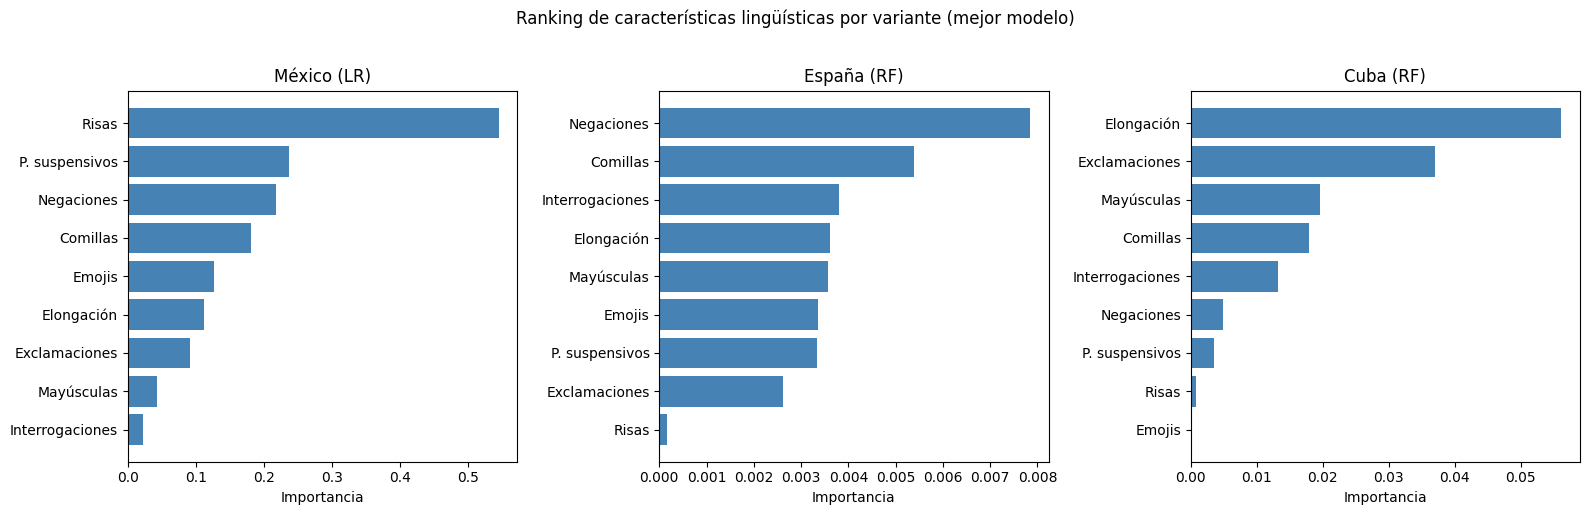

In [15]:
# Figura: ranking de importancias lingüísticas por variante (mejor modelo)
import numpy as np

NOMBRES_FEATURES = [
    'Exclamaciones', 'Interrogaciones', 'Mayúsculas',
    'Emojis', 'Risas', 'Negaciones',
    'Elongación', 'Comillas', 'P. suspensivos'
]

variantes_info = {
    'México':  ('mx', 'LR'),
    'España':  ('es', 'RF'),
    'Cuba':    ('cu', 'RF')
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (variante, (ds, modelo)) in zip(axes, variantes_info.items()):
    fila = df_feat[
        (df_feat['dataset'] == ds) &
        (df_feat['modelo'] == modelo)
    ].iloc[0]

    valores = [fila[col] for col in FEATURE_COLS]
    indices = np.argsort(valores)

    ax.barh(
        [NOMBRES_FEATURES[i] for i in indices],
        [valores[i] for i in indices],
        color='steelblue'
    )
    ax.set_title(f'{variante} ({modelo})')
    ax.set_xlabel('Importancia')

plt.suptitle('Ranking de características lingüísticas por variante (mejor modelo)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../data/figura_importancias_ling.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Análisis de errores — mejor modelo por variante
Matrices de confusión y ejemplos mal clasificados para el mejor modelo
de cada variante dialectal.

In [12]:
mejores = {}
for r in RESULTADOS:
    ds = r['dataset']
    if ds not in mejores or r['f1_macro'] > mejores[ds]['f1_macro']:
        mejores[ds] = r

for ds, r in mejores.items():
    prep          = r['prep']
    repr_nombre   = r['repr']
    modelo_nombre = r['modelo']
    estimator     = r['estimator']

    SUFIJO = '' if prep == 'normal' else f'_{prep}'
    df_te  = pd.read_csv(f'{DATA_DIR}/test_clean{SUFIJO}_{ds}.csv')

    if repr_nombre == 'TF-IDF':
        X_te = df_te[['MESSAGE_CLEAN'] + FEATURE_COLS]
    else:
        glove_te, _ = vectorizar_glove(df_te['MESSAGE_CLEAN'], glove)
        X_te = np.hstack([glove_te, df_te[FEATURE_COLS].values.astype(float)])

    y_te   = df_te['IS_IRONIC'].values
    y_pred = estimator.predict(X_te)

    print(f'\n{"="*60}')
    print(f'  MEJOR — {ds.upper()} | {prep.upper()} | {repr_nombre} | {modelo_nombre}')
    print(f'  F1-Macro test={r["f1_macro"]:.4f} | '
          f'Outer F1={r["outer_f1_mean"]:.4f}±{r["outer_f1_std"]:.4f}')
    print(f'{"="*60}')

    # Classification report
    print('\n── Classification report ──')
    print(classification_report(y_te, y_pred,
          target_names=['No irónico', 'Irónico']))

    # Matriz de confusión
    cm = confusion_matrix(y_te, y_pred)
    tn, fp_cm, fn_cm, tp = cm.ravel()
    print('── Matriz de confusión ──')
    print(f'                  Pred No irónico   Pred Irónico')
    print(f'  Real No irónico       {tn:>5}            {fp_cm:>5}')
    print(f'  Real Irónico          {fn_cm:>5}            {tp:>5}')

    # Ejemplos mal clasificados
    df_te_copy = df_te.copy()
    df_te_copy['y_pred'] = y_pred
    errores = df_te_copy[df_te_copy['IS_IRONIC'] != df_te_copy['y_pred']]
    fn_rows = errores[errores['IS_IRONIC'] == 1]
    fp_rows = errores[errores['IS_IRONIC'] == 0]

    print(f'\n── Ejemplos mal clasificados (máx. 5 por tipo) ──')
    print(f'  Falsos negativos ({len(fn_rows)} total):')
    for _, row in fn_rows.head(5).iterrows():
        print(f'    → {str(row["MESSAGE_CLEAN"])[:120]}')
    print(f'  Falsos positivos ({len(fp_rows)} total):')
    for _, row in fp_rows.head(5).iterrows():
        print(f'    → {str(row["MESSAGE_CLEAN"])[:120]}')


  MEJOR — MX | NORMAL | TF-IDF | LR
  F1-Macro test=0.6924 | Outer F1=0.6655±0.0130

── Classification report ──
              precision    recall  f1-score   support

  No irónico       0.79      0.80      0.80       401
     Irónico       0.59      0.58      0.59       199

    accuracy                           0.73       600
   macro avg       0.69      0.69      0.69       600
weighted avg       0.73      0.73      0.73       600

── Matriz de confusión ──
                  Pred No irónico   Pred Irónico
  Real No irónico         321               80
  Real Irónico             83              116

── Ejemplos mal clasificados (máx. 5 por tipo) ──
  Falsos negativos (83 total):
    → sii rusia cuba y china no quieren el petróleo ellos quieren las manzanas y los mangos seguramente qué atrevida es la ign
    → jajajaja ay no bueno que le falta que un pajarito le hable no es posible
    → [user] que se vayan a legislar a venezuela le harían muy bien al país jaja
    → me río de su in